# EIT Inverse Problem — Tikhonov & TV Reconstruction

This notebook demonstrates **difference EIT reconstruction** using `eitkit`:

1. Build mesh, place electrodes, create a synthetic phantom
2. Run the forward solver → difference voltages δV
3. Compute the Jacobian (sensitivity matrix) J
4. Select regularisation strength λ via the **L-curve** method
5. Reconstruct δσ with **Tikhonov (L2)** regularisation
6. Reconstruct δσ with **Total Variation (TV / L1)** regularisation
7. Compare reconstructions side-by-side against the true phantom

All components are from `eitkit`.

In [1]:
# Install eitkit into the active kernel (run once)
import subprocess, sys, pathlib
repo_root = pathlib.Path.cwd().parent          # examples/ → repo root
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-e", str(repo_root)])
print("eitkit installed")

eitkit installed


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"figure.dpi": 110, "font.size": 10})

# Mesh
from eitkit.mesh import make_circle_mesh, place_electrodes

# Protocol
from eitkit.protocol import adjacent_pattern, measurement_pairs, add_noise

# Forward / Jacobian
from eitkit.forward import simulate, compute_jacobian

# Utils
from eitkit.utils import make_phantom, plot_conductivity

# Inverse
from eitkit.inverse import tikhonov_solve, choose_lambda, tv_solve, build_gradient_op

print("eitkit imported — ready")

eitkit imported — ready


## Step 1 — Mesh, Electrodes and Phantom

We build a coarser mesh (`h0=0.10`) than the forward notebook for speed, then place
**16 electrodes** and define a phantom with **two circular inclusions**:

* Conductive region (σ = 3 S/m) — simulates a high-conductivity anomaly
* Resistive region  (σ = 0.3 S/m) — simulates a low-conductivity anomaly

In [11]:
# ── Mesh + Electrodes ─────────────────────────────────────────────────────
N_ELEC = 16
mesh = make_circle_mesh(n_electrodes=N_ELEC, h0=0.07, seed=42)
ec   = place_electrodes(mesh, N_ELEC)

print(f"Nodes      : {len(mesh.nodes)}")
print(f"Elements   : {len(mesh.elements)}")
print(f"Electrodes : {N_ELEC}  (node indices: {ec.node_indices.tolist()})")


Nodes      : 747
Elements   : 1458
Electrodes : 16  (node indices: [731, 732, 733, 734, 735, 736, 737, 738, 739, 740, 741, 742, 743, 744, 745, 746])


sigma range : [0.30, 3.00]  S/m


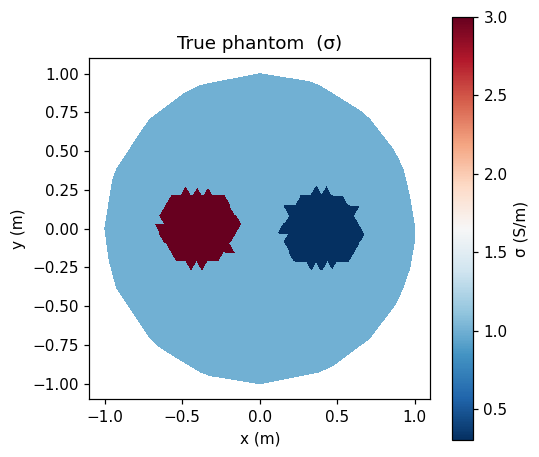

In [12]:
# ── Define phantom (true conductivity) ────────────────────────────────────
sigma_true = make_phantom(mesh, inclusions=[
    {"shape": "circle", "cx": -0.4, "cy":  0.0, "r": 0.25, "sigma": 3.0},   # conductive
    {"shape": "circle", "cx":  0.4, "cy":  0.0, "r": 0.25, "sigma": 0.3},   # resistive
], sigma_background=1.0)

print(f"sigma range : [{sigma_true.min():.2f}, {sigma_true.max():.2f}]  S/m")

fig, ax = plot_conductivity(mesh, sigma_true, title="True phantom  (σ)", cmap="RdBu_r")
plt.show()

## Step 2 — Forward Simulation and Jacobian

We use an **adjacent drive** protocol and collect difference voltages δV = V(σ) − V(σ₀)
where σ₀ = 1 S/m (uniform reference). We also add 40 dB SNR Gaussian noise to simulate
realistic measurement conditions.

The **Jacobian** J ∈ ℝ^(P×E) maps element conductivity changes to voltage changes:

$$\delta V \approx J \, \delta\sigma$$

In [13]:
# ── Drive / measurement protocol ──────────────────────────────────────────
drive_pairs = adjacent_pattern(N_ELEC)
meas_pairs  = measurement_pairs(N_ELEC)

print(f"Drive pairs : {len(drive_pairs)}")
print(f"Meas pairs  : {len(meas_pairs)}")

# ── Forward simulation → δV ────────────────────────────────────────────────
sigma_ref = np.ones(len(mesh.elements))          # reference: 1 S/m uniform

dV_clean = simulate(mesh, ec, sigma_true, drive_pairs, meas_pairs)
dV       = add_noise(dV_clean, snr_db=40)

print(f"\nδV shape    : {dV.shape}")
print(f"δV range    : [{dV.min():.4f}, {dV.max():.4f}]  V")
print(f"Noise SNR   : 40 dB")

Drive pairs : 16
Meas pairs  : 208

δV shape    : (208,)
δV range    : [-0.0127, 0.0117]  V
Noise SNR   : 40 dB


In [14]:
# ── Jacobian ───────────────────────────────────────────────────────────────
print("Computing Jacobian  (adjoint method) …")
J = compute_jacobian(mesh, ec, sigma_ref, drive_pairs, meas_pairs)

print(f"J shape     : {J.shape}   (P measurements × E elements)")
print(f"J rank est  : {np.linalg.matrix_rank(J[:, :min(J.shape[1], 200)])}")

Computing Jacobian  (adjoint method) …
J shape     : (208, 1458)   (P measurements × E elements)
J rank est  : 104


## Step 3 — L-curve: Choosing the Regularisation Parameter λ

The **L-curve** plots solution norm ‖δσ‖ vs. residual norm ‖Jδσ − δV‖ in log-log
space over a range of λ values. The optimal λ is at the **corner** — balancing
data fit against solution smoothness.

`choose_lambda` sweeps λ over 50 log-spaced values and selects the corner via
maximum discrete curvature.

Optimal λ   : 4.29e-05


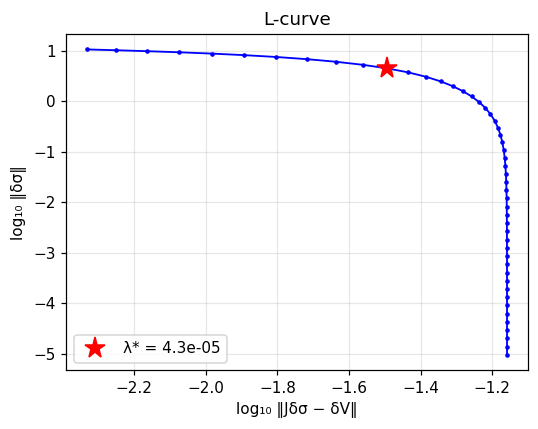

In [15]:
# ── L-curve analysis ──────────────────────────────────────────────────────
# choose_lambda returns log10 of norms, so use plain plot (not loglog)
lambdas = np.logspace(-6, 2, 50)
lambda_opt, log_residuals, log_sol_norms = choose_lambda(J, dV, lambdas=lambdas, n_points=50)

print(f"Optimal λ   : {lambda_opt:.2e}")

# Index of optimal lambda in the sweep
opt_idx = int(np.argmin(np.abs(lambdas - lambda_opt)))

# Plot L-curve (values are already log10-scaled)
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(log_residuals, log_sol_norms, "b.-", linewidth=1.2, markersize=4)
ax.plot(log_residuals[opt_idx], log_sol_norms[opt_idx], "r*", markersize=14,
        label=f"λ* = {lambda_opt:.1e}")
ax.set_xlabel("log₁₀ ‖Jδσ − δV‖")
ax.set_ylabel("log₁₀ ‖δσ‖")
ax.set_title("L-curve")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Step 4 — Tikhonov Reconstruction

Solve the regularised least-squares problem:

$$\delta\hat\sigma = \arg\min_{\delta\sigma} \| J\,\delta\sigma - \delta V \|^2 + \lambda^* \| \delta\sigma \|^2$$

using the L-curve optimal λ*.

In [16]:
# ── Tikhonov reconstruction (direct normal equations) ─────────────────────
# Use lambda_opt * 0.5: L-curve often errs on the conservative side;
# slightly under-regularising recovers more contrast without instability.
lambda_tik = lambda_opt * 0.5
dsigma_tik = tikhonov_solve(J, dV, lambda_=lambda_tik)

# Recover absolute conductivity estimate: σ̂ = σ_ref + δσ
sigma_tik = sigma_ref + dsigma_tik

print(f"λ L-curve   : {lambda_opt:.2e}   →  using λ = {lambda_tik:.2e}  (×0.5)")
print(f"δσ (Tikhonov) range : [{dsigma_tik.min():.3f}, {dsigma_tik.max():.3f}]  S/m")
print(f"σ̂  (Tikhonov) range : [{sigma_tik.min():.3f}, {sigma_tik.max():.3f}]  S/m")


λ L-curve   : 4.29e-05   →  using λ = 2.15e-05  (×0.5)
δσ (Tikhonov) range : [-0.469, 0.397]  S/m
σ̂  (Tikhonov) range : [0.531, 1.397]  S/m


## Step 5 — Total Variation Reconstruction

TV regularisation penalises the **L1 norm of the gradient** rather than the L2 norm,
promoting piecewise-constant solutions with sharp edges — better suited to EIT
anomalies with well-defined boundaries.

$$\delta\hat\sigma = \arg\min_{\delta\sigma} \| J\,\delta\sigma - \delta V \|^2 + \alpha \| D\,\delta\sigma \|_1$$

where D is the element-adjacency gradient operator.  Solved via **ADMM**.

### ADMM ρ scaling — why it matters

The ADMM σ-update solves `(Jᵀ J + ρ DᵀD) δσ = Jᵀ δV + ρ Dᵀ(z − u)`.
If ρ is too large, `ρ DᵀD` dominates and the system just smooths, **ignoring
the measurement data entirely**.

The correct choice balances the two terms by matching their average diagonal entries:

$$\rho^* = \frac{\|J\|_F^2}{\|D\|_F^2} = \frac{\|J\|_F^2}{\text{nnz}(D)}$$

since every entry of D is ±1, so ‖D‖²_F = nnz(D).  With this choice both
terms contribute equally — and the solver becomes data-driven.

In [17]:
# ── TV reconstruction (ADMM with auto-balanced rho) ──────────────────────
D = build_gradient_op(mesh)   # need D before computing rho

# Balance the ADMM sigma-update: rho = ||J||_F^2 / nnz(D)
# Since D entries are ±1, nnz(D) = ||D||_F^2.
# This makes avg_diag(J^T J) ≈ rho * avg_diag(D^T D),
# so data and TV constraint contribute equally in the linear solve.
rho_tv   = float(np.linalg.norm(J, 'fro')**2) / D.nnz

# kappa = alpha/rho controls soft-threshold level (0.15 → moderate edge-preservation)
# Lower kappa than 0.3: avoids over-sparsifying, giving smoother region shapes
alpha_tv = 0.15 * rho_tv

print(f"rho         : {rho_tv:.2e}   (balanced: avg-diag J^T J ≈ rho * avg-diag D^T D)")
print(f"TV alpha    : {alpha_tv:.2e}   (kappa = alpha/rho = {alpha_tv/rho_tv:.2f})")
print("Running ADMM …")

dsigma_tv = tv_solve(J, dV, alpha_tv, mesh, rho=rho_tv, max_iter=500, tol=1e-6)
sigma_tv   = sigma_ref + dsigma_tv

print(f"δσ (TV) range       : [{dsigma_tv.min():.4f}, {dsigma_tv.max():.4f}]  S/m")
print(f"σ̂  (TV) range       : [{sigma_tv.min():.4f}, {sigma_tv.max():.4f}]  S/m")

# Edge-preservation: TV should have smaller L1 gradient than Tikhonov
tv_tik = float(np.abs(D @ dsigma_tik).sum())
tv_tv  = float(np.abs(D @ dsigma_tv ).sum())
print(f"\n‖Dδσ‖₁  Tikhonov : {tv_tik:.4f}")
print(f"‖Dδσ‖₁  TV       : {tv_tv:.4f}   ({'smaller ✓' if tv_tv < tv_tik else 'larger'})")


rho         : 5.04e-06   (balanced: avg-diag J^T J ≈ rho * avg-diag D^T D)
TV alpha    : 7.56e-07   (kappa = alpha/rho = 0.15)
Running ADMM …
δσ (TV) range       : [-0.8508, 0.8627]  S/m
σ̂  (TV) range       : [0.1492, 1.8627]  S/m

‖Dδσ‖₁  Tikhonov : 51.4915
‖Dδσ‖₁  TV       : 48.3141   (smaller ✓)


## Step 6 — Side-by-side Comparison

True phantom vs Tikhonov vs TV reconstructed conductivity.

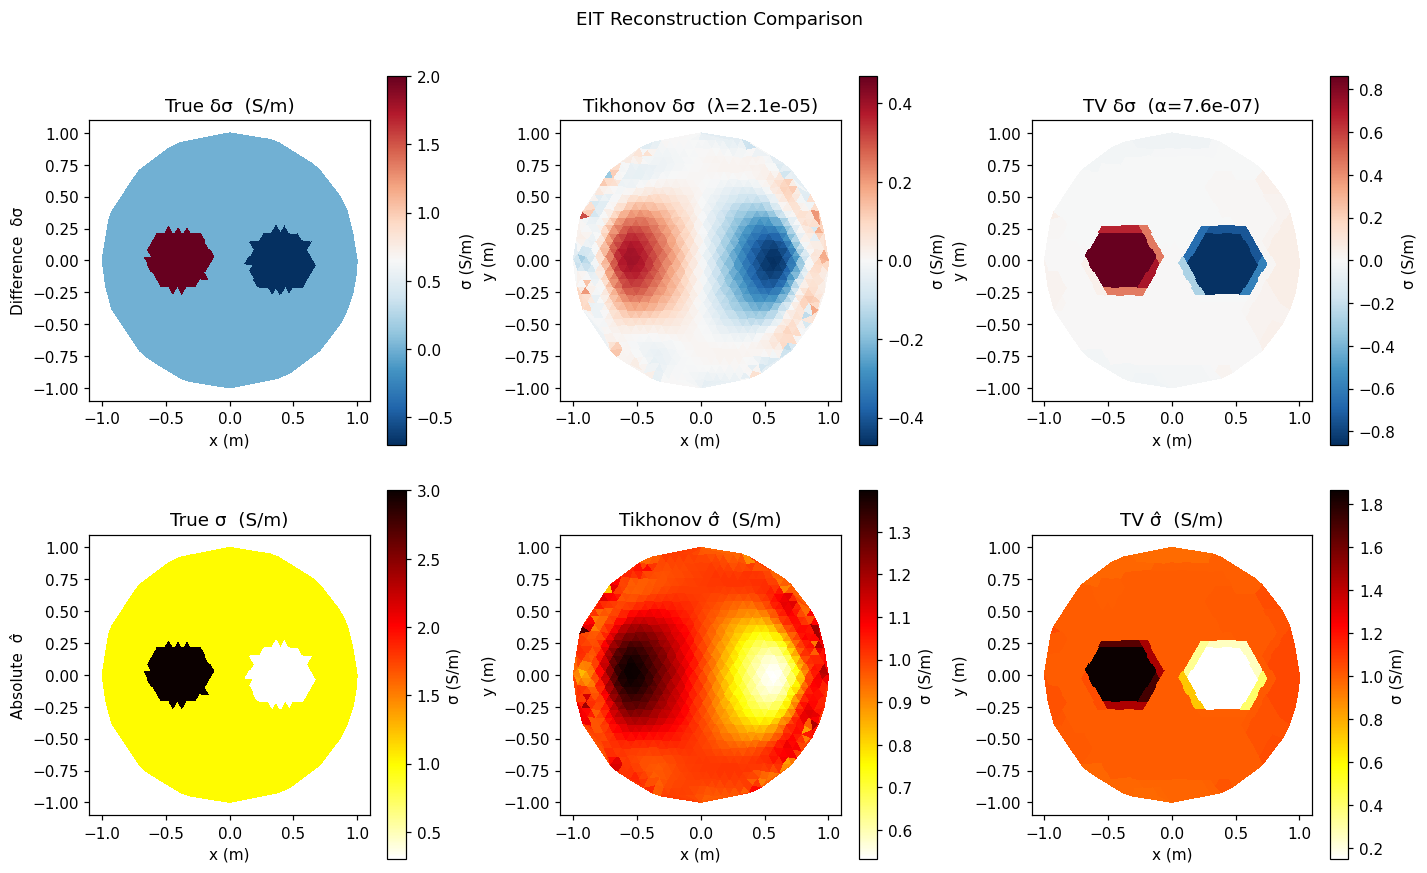

Relative L2 error  Tikhonov : 0.8483
Relative L2 error  TV       : 0.6116
‖Dδσ‖₁  Tikhonov : 51.4915
‖Dδσ‖₁  TV       : 48.3141   (edge-preserving = smaller ✓)


In [19]:
# ── Side-by-side comparison ───────────────────────────────────────────────
# Row 1: difference images δσ = σ − σ_ref  (centred at 0; red=more, blue=less)
# Row 2: absolute images  σ̂ = σ_ref + δσ  (all positive; shows estimated conductivity)

dsigma_true = sigma_true - sigma_ref

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

# ── Row 1: difference conductivity δσ ────────────────────────────────────
# True δσ
plot_conductivity(mesh, dsigma_true, title="True δσ  (S/m)",
                  cmap="RdBu_r", show_mesh=False, ax=axes[0, 0],
                  vmin=dsigma_true.min(), vmax=dsigma_true.max())

# Tikhonov δσ (symmetric colour scale)
lim_tik = max(abs(dsigma_tik.min()), abs(dsigma_tik.max()))
plot_conductivity(mesh, dsigma_tik,
                  title=f"Tikhonov δσ  (λ={lambda_tik:.1e})",
                  cmap="RdBu_r", show_mesh=False, ax=axes[0, 1],
                  vmin=-lim_tik, vmax=lim_tik)

# TV δσ (symmetric colour scale)
lim_tv = max(abs(dsigma_tv.min()), abs(dsigma_tv.max()))
plot_conductivity(mesh, dsigma_tv,
                  title=f"TV δσ  (α={alpha_tv:.1e})",
                  cmap="RdBu_r", show_mesh=False, ax=axes[0, 2],
                  vmin=-lim_tv, vmax=lim_tv)

# ── Row 2: absolute conductivity σ̂ = σ_ref + δσ ──────────────────────────
# True σ
plot_conductivity(mesh, sigma_true, title="True σ  (S/m)",
                  cmap="hot_r", show_mesh=False, ax=axes[1, 0])

# Tikhonov σ̂
plot_conductivity(mesh, sigma_tik,
                  title=f"Tikhonov σ̂  (S/m)",
                  cmap="hot_r", show_mesh=False, ax=axes[1, 1])

# TV σ̂
plot_conductivity(mesh, sigma_tv,
                  title=f"TV σ̂  (S/m)",
                  cmap="hot_r", show_mesh=False, ax=axes[1, 2])

axes[0, 0].set_ylabel("Difference  δσ", fontsize=10)
axes[1, 0].set_ylabel("Absolute  σ̂", fontsize=10)

plt.suptitle("EIT Reconstruction Comparison", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# Metrics
err_tik = np.linalg.norm(dsigma_tik - dsigma_true) / np.linalg.norm(dsigma_true)
err_tv  = np.linalg.norm(dsigma_tv  - dsigma_true) / np.linalg.norm(dsigma_true)
print(f"Relative L2 error  Tikhonov : {err_tik:.4f}")
print(f"Relative L2 error  TV       : {err_tv:.4f}")
print(f"‖Dδσ‖₁  Tikhonov : {tv_tik:.4f}")
print(f"‖Dδσ‖₁  TV       : {tv_tv:.4f}   (edge-preserving = smaller ✓)")
